# SOLEXS Multi-Energy Adaptive Binning Notebook

This notebook stops at the light-curve stage.

It does four things only:
1. loads the low/mid/high energy light curves,
2. runs Bayesian Blocks on each light curve,
3. refines the flare region with recursive splitting,
4. chooses the finest time binning obtained across the energy bands.

No spectra, no fitting, and no merging are included.

## Workflow

For each energy band, the notebook:
- reads the light curve,
- estimates the flare region from Bayesian Blocks,
- refines the flare region with recursive splitting,
- plots the Bayesian Blocks and the final split intervals,
- compares the bin durations across energy bands.

The final binning is taken from the band that produces the smallest adaptive time bins.

In [1]:
from __future__ import annotations

import csv
import json
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import bayesian_blocks as astropy_bayesian_blocks

plt.rcParams["figure.dpi"] = 120

## Configuration

Update the paths below to point to your light-curve files.

The notebook accepts FITS/LC files and CSV files.
It also tolerates either numeric Unix time columns or ISO datetime strings.

In [2]:
BASE = Path("/home/manan/solexs_project/Solar_Flare_2024_07-17")
OUT_DIR = BASE / "multi_energy_binning"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LIGHTCURVE_SOURCES = [
    {
        "name": "low_energy",
        "label": "Low energy",
        "path": BASE / "lightcurves" / "low_energy.lc",
    },
    {
        "name": "mid_energy",
        "label": "Mid energy",
        "path": BASE / "lightcurves" / "mid_energy.lc",
    },
    {
        "name": "high_energy",
        "label": "High energy",
        "path": BASE / "lightcurves" / "high_energy.lc",
    },
    {
        "name": "very_high_energy",
        "label": " Very High energy",
        "path": BASE / "lightcurves" / "vhigh_energy.lc",
    },
    {
        "name": "Full_energy",
        "label": " Full energy",
        "path": BASE / "lightcurves" / "full_energy.lc",
    },
]

P0 = 0.01
FLARE_SNR_THRESHOLD = 3.0
MIN_BIN_WIDTH = 5.0
MAX_DEPTH = 6
MIN_COUNTS = 1200.0
MIN_SNR = 30.0
SPLIT_SCORE_THRESHOLD = 0.35
SMOOTH_WINDOW = 5

## Light-curve reader

The reader keeps the notebook flexible:
- FITS table files are supported,
- CSV files are supported,
- time can be Unix seconds or ISO strings,
- counts, rate, and uncertainty are inferred when needed.

In [3]:
@dataclass
class InputLC:
    time: np.ndarray
    start: np.ndarray
    stop: np.ndarray
    width: np.ndarray
    counts: np.ndarray
    rate: np.ndarray
    rate_err: np.ndarray
    source: str
    meta: Dict[str, Any]


def _is_fits_like(path: str) -> bool:
    s = str(path).lower()
    return any(s.endswith(ext) for ext in [".fits", ".fit", ".fts", ".lc", ".fits.gz", ".fit.gz", ".fts.gz", ".lc.gz"])


def _lookup_pick(columns: Sequence[str], *names: Optional[str]) -> Optional[str]:
    lookup = {str(c).strip().upper(): c for c in columns}
    for n in names:
        if n is None:
            continue
        key = str(n).strip().upper()
        if key in lookup:
            return lookup[key]
    return None


def _coerce_time_column(values: Sequence[Any]) -> np.ndarray:
    arr = pd.Series(list(values))
    numeric = pd.to_numeric(arr, errors="coerce")
    if numeric.notna().mean() > 0.9:
        return numeric.to_numpy(dtype=float)

    dt = pd.to_datetime(arr, utc=True, errors="coerce")
    if dt.notna().any():
        return (dt.view("int64").to_numpy(dtype=float) / 1e9)

    raise ValueError("Could not parse time column as numeric or datetime.")


def _parse_float_array(values: Sequence[Any]) -> np.ndarray:
    return pd.to_numeric(pd.Series(list(values)), errors="coerce").to_numpy(dtype=float)


def _infer_edges_from_centers(t: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        half = 0.5
        return np.array([t[0] - half]), np.array([t[0] + half])

    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    step = float(np.median(dt)) if len(dt) else 1.0

    edges = np.zeros(len(t) + 1, dtype=float)
    edges[1:-1] = 0.5 * (t[:-1] + t[1:])
    edges[0] = t[0] - 0.5 * step
    edges[-1] = t[-1] + 0.5 * step

    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-9

    return edges[:-1], edges[1:]


def read_lightcurve(
    path: str | Path,
    timecol: str = "TIME",
    countscol: Optional[str] = None,
    ratecol: Optional[str] = None,
    errcol: Optional[str] = None,
    widthcol: Optional[str] = None,
    startcol: Optional[str] = None,
    stopcol: Optional[str] = None,
    hdu: int = 1,
) -> InputLC:
    path = Path(path)

    if _is_fits_like(str(path)):
        with fits.open(path) as hdul:
            if hdu >= len(hdul):
                raise ValueError(f"HDU {hdu} not found in {path}")
            data = hdul[hdu].data
            if data is None:
                raise ValueError(f"No table data found in FITS HDU {hdu}")
            cols = list(data.names)

            timecol = _lookup_pick(cols, timecol, "TIME", "time")
            countscol = _lookup_pick(cols, countscol, "COUNTS", "counts", "NCOUNTS")
            ratecol = _lookup_pick(cols, ratecol, "RATE", "rate", "CR", "COUNT_RATE")
            errcol = _lookup_pick(cols, errcol, "ERROR", "ERR", "RATE_ERR", "STAT_ERR", "sigma")
            widthcol = _lookup_pick(cols, widthcol, "TIMEDEL", "WIDTH", "DT", "BINWIDTH", "EXPOSURE")
            startcol = _lookup_pick(cols, startcol, "TSTART", "START", "BINSTART")
            stopcol = _lookup_pick(cols, stopcol, "TSTOP", "STOP", "BINSTOP")

            if timecol is None:
                raise ValueError(f"No TIME-like column found. Available columns: {cols}")

            time = _coerce_time_column(data[timecol])
            counts = _parse_float_array(data[countscol]) if countscol else None
            rate = _parse_float_array(data[ratecol]) if ratecol else None
            err = _parse_float_array(data[errcol]) if errcol else None

            if startcol and stopcol:
                start = _coerce_time_column(data[startcol])
                stop = _coerce_time_column(data[stopcol])
                width = stop - start
                time = 0.5 * (start + stop)
            elif widthcol:
                width = _parse_float_array(data[widthcol])
                start = time - 0.5 * width
                stop = time + 0.5 * width
            else:
                start, stop = _infer_edges_from_centers(time)
                width = stop - start

    else:
        with open(path, newline="") as f:
            reader = csv.DictReader(f)
            if reader.fieldnames is None:
                raise ValueError(f"No columns found in {path}")
            cols = [c.strip() for c in reader.fieldnames]
            rows = list(reader)

        timecol = _lookup_pick(cols, timecol, "TIME", "time", "MID_TIME", "mid_time")
        countscol = _lookup_pick(cols, countscol, "COUNTS", "counts", "NCOUNTS")
        ratecol = _lookup_pick(cols, ratecol, "RATE", "rate", "COUNT_RATE")
        errcol = _lookup_pick(cols, errcol, "ERROR", "ERR", "RATE_ERR", "sigma")
        widthcol = _lookup_pick(cols, widthcol, "TIMEDEL", "WIDTH", "DT", "BINWIDTH", "EXPOSURE")
        startcol = _lookup_pick(cols, startcol, "TSTART", "START", "BINSTART")
        stopcol = _lookup_pick(cols, stopcol, "TSTOP", "STOP", "BINSTOP")

        if timecol is None:
            raise ValueError(f"No TIME-like column found in {path}. Available columns: {cols}")

        time = _coerce_time_column([r.get(timecol) for r in rows])
        counts = _parse_float_array([r.get(countscol) for r in rows]) if countscol else None
        rate = _parse_float_array([r.get(ratecol) for r in rows]) if ratecol else None
        err = _parse_float_array([r.get(errcol) for r in rows]) if errcol else None

        if startcol and stopcol:
            start = _coerce_time_column([r.get(startcol) for r in rows])
            stop = _coerce_time_column([r.get(stopcol) for r in rows])
            width = stop - start
            time = 0.5 * (start + stop)
        elif widthcol:
            width = _parse_float_array([r.get(widthcol) for r in rows])
            start = time - 0.5 * width
            stop = time + 0.5 * width
        else:
            start, stop = _infer_edges_from_centers(time)
            width = stop - start

    mask = np.isfinite(time) & np.isfinite(start) & np.isfinite(stop) & np.isfinite(width)
    if counts is not None:
        mask &= np.isfinite(counts)
    if rate is not None:
        mask &= np.isfinite(rate)
    if err is not None:
        mask &= np.isfinite(err)

    time = time[mask]
    start = start[mask]
    stop = stop[mask]
    width = width[mask]

    if counts is not None:
        counts = counts[mask]
    if rate is not None:
        rate = rate[mask]
    if err is not None:
        err = err[mask]

    order = np.argsort(time)
    time = time[order]
    start = start[order]
    stop = stop[order]
    width = width[order]

    if counts is not None:
        counts = counts[order]
    if rate is not None:
        rate = rate[order]
    if err is not None:
        err = err[order]

    if len(time) < 2:
        raise ValueError("Need at least two valid light-curve rows.")

    if counts is None and rate is not None:
        counts = rate * width
    elif counts is None:
        raise ValueError("No counts or rate data found.")

    if rate is None:
        rate = counts / np.maximum(width, 1e-12)

    if err is None:
        err = np.sqrt(np.maximum(counts, 1.0)) / np.maximum(width, 1e-12)

    meta = {
        "path": str(path),
        "is_fits": _is_fits_like(str(path)),
        "timecol": timecol,
        "countscol": countscol,
        "ratecol": ratecol,
        "errcol": errcol,
        "widthcol": widthcol,
        "startcol": startcol,
        "stopcol": stopcol,
    }

    return InputLC(
        time=np.asarray(time, dtype=float),
        start=np.asarray(start, dtype=float),
        stop=np.asarray(stop, dtype=float),
        width=np.asarray(width, dtype=float),
        counts=np.asarray(counts, dtype=float),
        rate=np.asarray(rate, dtype=float),
        rate_err=np.asarray(err, dtype=float),
        source=str(path),
        meta=meta,
    )

## Bayesian Blocks and recursive splitting

This section keeps only the light-curve logic:

- Bayesian Blocks gives the first segmentation,
- the flare region is identified from SNR,
- recursive splitting refines intervals where the light curve changes rapidly,
- no merging is performed.

In [4]:
def bayesian_blocks_measures(
    t: np.ndarray,
    x: np.ndarray,
    sigma: np.ndarray,
    p0: float = P0,
) -> np.ndarray:
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    if len(t) != len(x) or len(t) != len(sigma):
        raise ValueError("t, x, sigma must have the same length.")
    return astropy_bayesian_blocks(t=t, x=x, sigma=sigma, fitness="measures", p0=p0)


def make_block_table(lc: InputLC, edges: np.ndarray) -> pd.DataFrame:
    rows = []
    for i in range(len(edges) - 1):
        s = float(edges[i])
        e = float(edges[i + 1])
        mask = (lc.time >= s) & (lc.time < e)
        if not np.any(mask):
            continue
        counts = float(np.sum(lc.counts[mask]))
        duration = max(e - s, 1e-12)
        rate = counts / duration
        rows.append({"start": s, "stop": e, "duration": duration, "counts": counts, "rate": rate})
    return pd.DataFrame(rows)


def add_snr_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["sigma"] = np.sqrt(np.maximum(out["counts"], 1.0))
    out["snr"] = out["counts"] / out["sigma"]
    return out


def contiguous_true_run(mask: np.ndarray) -> Tuple[int, int]:
    mask = np.asarray(mask, dtype=bool)
    best_s, best_e = 0, 0
    cur_s = None

    for i, v in enumerate(mask):
        if v and cur_s is None:
            cur_s = i
        elif (not v) and cur_s is not None:
            if i - cur_s > best_e - best_s:
                best_s, best_e = cur_s, i
            cur_s = None

    if cur_s is not None and len(mask) - cur_s > best_e - best_s:
        best_s, best_e = cur_s, len(mask)

    return best_s, best_e


def detect_flare_region(blocks: pd.DataFrame, flare_snr: float = FLARE_SNR_THRESHOLD) -> Tuple[int, int]:
    if len(blocks) == 0:
        return 0, 0
    mask = blocks["snr"].to_numpy() >= flare_snr
    if not np.any(mask):
        i = int(np.nanargmax(blocks["snr"].to_numpy()))
        return max(0, i - 1), min(len(blocks), i + 2)
    return contiguous_true_run(mask)


def smooth_rate(rate: np.ndarray, window: int = SMOOTH_WINDOW) -> np.ndarray:
    rate = np.asarray(rate, dtype=float)
    if window < 3 or len(rate) < window:
        return rate.copy()
    kernel = np.ones(window, dtype=float) / float(window)
    return np.convolve(rate, kernel, mode="same")


def interval_stats(lc: InputLC, start: float, stop: float) -> Dict[str, float]:
    mask = (lc.time >= start) & (lc.time < stop)
    duration = max(float(stop - start), 0.0)

    if np.count_nonzero(mask) == 0:
        return {"counts": 0.0, "duration": duration, "rate": 0.0, "sigma": 0.0, "snr": 0.0}

    counts = float(np.sum(lc.counts[mask]))
    rate = counts / duration if duration > 0 else 0.0
    sigma = math.sqrt(max(counts, 1.0))
    snr = counts / sigma if sigma > 0 else 0.0

    return {"counts": counts, "duration": duration, "rate": rate, "sigma": sigma, "snr": snr}


def fractional_variation(lc: InputLC, start: float, stop: float) -> float:
    mask = (lc.time >= start) & (lc.time < stop)
    if np.count_nonzero(mask) < 3:
        return 0.0

    rate = smooth_rate(lc.rate[mask], window=min(SMOOTH_WINDOW, np.count_nonzero(mask)))
    if len(rate) < 3:
        return 0.0

    denom = float(np.nanmean(rate))
    if not np.isfinite(denom) or abs(denom) < 1e-12:
        return 0.0

    return float(np.nanstd(rate) / abs(denom))


def best_split_point(lc: InputLC, start: float, stop: float) -> Tuple[float, float]:
    mask = (lc.time >= start) & (lc.time < stop)
    t = lc.time[mask]
    r = lc.rate[mask]

    if len(t) < 4:
        return 0.5 * (start + stop), 0.0

    best_score = -np.inf
    best_t = 0.5 * (start + stop)

    for k in range(2, len(t) - 1):
        left = r[:k]
        right = r[k:]
        if len(left) < 2 or len(right) < 2:
            continue

        ml = float(np.nanmean(left))
        mr = float(np.nanmean(right))
        sl = float(np.nanstd(left))
        sr = float(np.nanstd(right))
        denom = sl + sr + 1e-12
        score = abs(ml - mr) / denom

        if score > best_score:
            best_score = score
            best_t = 0.5 * (t[k - 1] + t[k])

    if not np.isfinite(best_score):
        return 0.5 * (start + stop), 0.0

    return float(best_t), float(best_score)


def split_interval(
    lc: InputLC,
    start: float,
    stop: float,
    depth: int = 0,
    min_bin_width: float = MIN_BIN_WIDTH,
    max_depth: int = MAX_DEPTH,
    min_counts: float = MIN_COUNTS,
    min_snr: float = MIN_SNR,
    split_score_threshold: float = SPLIT_SCORE_THRESHOLD,
) -> List[Tuple[float, float]]:
    st = interval_stats(lc, start, stop)
    duration = st["duration"]
    counts = st["counts"]
    snr = st["snr"]
    interval_var = fractional_variation(lc, start, stop)
    split_t, local_score = best_split_point(lc, start, stop)

    if depth >= max_depth:
        return [(float(start), float(stop))]
    if duration <= min_bin_width:
        return [(float(start), float(stop))]
    if counts < min_counts and duration <= 2.0 * min_bin_width:
        return [(float(start), float(stop))]
    if snr < min_snr and duration <= 2.5 * min_bin_width:
        return [(float(start), float(stop))]

    should_split = (local_score >= split_score_threshold) or (interval_var >= 0.20) or (duration > 4.0 * min_bin_width)
    if not should_split:
        return [(float(start), float(stop))]

    split_t = float(np.clip(split_t, start + min_bin_width, stop - min_bin_width))
    if not np.isfinite(split_t) or split_t <= start or split_t >= stop:
        return [(float(start), float(stop))]

    left = split_interval(
        lc, start, split_t, depth=depth + 1,
        min_bin_width=min_bin_width, max_depth=max_depth, min_counts=min_counts,
        min_snr=min_snr, split_score_threshold=split_score_threshold
    )
    right = split_interval(
        lc, split_t, stop, depth=depth + 1,
        min_bin_width=min_bin_width, max_depth=max_depth, min_counts=min_counts,
        min_snr=min_snr, split_score_threshold=split_score_threshold
    )
    return left + right


def sanitize_intervals(intervals: Sequence[Tuple[float, float]]) -> List[Tuple[float, float]]:
    cleaned = []
    for s, e in intervals:
        s = float(s)
        e = float(e)
        if np.isfinite(s) and np.isfinite(e) and e > s:
            cleaned.append((s, e))
    cleaned.sort(key=lambda x: x[0])
    return cleaned


def build_band_bins(lc: InputLC, p0: float = P0) -> Dict[str, Any]:
    counts_err = np.sqrt(np.maximum(lc.counts, 1.0))
    bb_edges = bayesian_blocks_measures(lc.time, lc.counts, counts_err, p0=p0)

    blocks = make_block_table(lc, bb_edges)
    blocks = add_snr_columns(blocks)
    flare_start_idx, flare_stop_idx = detect_flare_region(blocks, flare_snr=FLARE_SNR_THRESHOLD)

    refined: List[Tuple[float, float]] = []
    for idx, row in blocks.iterrows():
        s = float(row["start"])
        e = float(row["stop"])
        if idx < flare_start_idx or idx >= flare_stop_idx:
            refined.append((s, e))
        else:
            refined.extend(
                split_interval(
                    lc,
                    s,
                    e,
                    depth=0,
                    min_bin_width=MIN_BIN_WIDTH,
                    max_depth=MAX_DEPTH,
                    min_counts=MIN_COUNTS,
                    min_snr=MIN_SNR,
                    split_score_threshold=SPLIT_SCORE_THRESHOLD,
                )
            )

    refined = sanitize_intervals(refined)

    refined_rows = []
    for i, (s, e) in enumerate(refined, start=1):
        st = interval_stats(lc, s, e)
        refined_rows.append(
            {
                "bin_no": i,
                "start": s,
                "stop": e,
                "duration": st["duration"],
                "counts": st["counts"],
                "rate": st["rate"],
                "snr": st["snr"],
            }
        )

    refined_df = pd.DataFrame(refined_rows)
    if len(refined_df):
        refined_df["mid_time"] = 0.5 * (refined_df["start"] + refined_df["stop"])

    meta = {
        "flare_start_idx": int(flare_start_idx),
        "flare_stop_idx": int(flare_stop_idx),
        "flare_start": float(blocks["start"].iloc[flare_start_idx]) if len(blocks) else float(lc.start[0]),
        "flare_stop": float(blocks["stop"].iloc[max(flare_stop_idx - 1, 0)]) if len(blocks) else float(lc.stop[-1]),
        "n_raw_blocks": int(len(blocks)),
        "n_final_bins": int(len(refined_df)),
        "min_duration": float(refined_df["duration"].min()) if len(refined_df) else np.nan,
        "median_duration": float(refined_df["duration"].median()) if len(refined_df) else np.nan,
    }

    return {
        "lc": lc,
        "bb_edges": bb_edges,
        "blocks": blocks,
        "refined_df": refined_df,
        "refined_intervals": refined,
        "meta": meta,
    }

## Load the band light curves

Add or change the files in `LIGHTCURVE_SOURCES`, then run this cell.

The notebook will build the Bayesian Blocks and the refined split intervals for each band.

In [5]:
band_results: Dict[str, Dict[str, Any]] = {}

for item in LIGHTCURVE_SOURCES:
    path = Path(item["path"])
    if not path.exists():
        print(f"Skipping missing file: {path}")
        continue

    lc = read_lightcurve(path)
    result = build_band_bins(lc, p0=P0)
    result["name"] = item["name"]
    result["label"] = item["label"]
    band_results[item["name"]] = result

print(f"Loaded bands: {list(band_results.keys())}")

Loaded bands: ['low_energy', 'mid_energy', 'high_energy', 'very_high_energy', 'Full_energy']


## Per-band summaries

This table helps compare the raw Bayesian Blocks with the refined split intervals for each energy band.

In [6]:
summary_rows = []
for name, result in band_results.items():
    meta = result["meta"]
    summary_rows.append(
        {
            "name": name,
            "label": result["label"],
            "n_raw_blocks": meta["n_raw_blocks"],
            "n_final_bins": meta["n_final_bins"],
            "min_duration": meta["min_duration"],
            "median_duration": meta["median_duration"],
            "flare_start": meta["flare_start"],
            "flare_stop": meta["flare_stop"],
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("min_duration", ascending=True)
summary_df

,name,label,n_raw_blocks,n_final_bins,min_duration,median_duration,flare_start,flare_stop
0,low_energy,Low energy,49,266,1.0,5.0,1.721198e+09,1.721200e+09
1,mid_energy,Mid energy,30,194,1.0,5.0,1.721198e+09,1.721200e+09
2,high_energy,High energy,12,56,1.0,5.0,1.721198e+09,1.721199e+09
4,Full_energy,Full energy,53,275,1.0,5.0,1.721198e+09,1.721200e+09
3,very_high_energy,Very High energy,3,23,5.0,5.0,1.721198e+09,1.721200e+09


## Pick the final time bins

The final bins are taken from the band that reaches the smallest adaptive bin width.
This gives a simple, computation-light choice with no merging stage.

In [7]:
if len(summary_df) == 0:
    raise RuntimeError("No light curves were loaded. Check the file paths in LIGHTCURVE_SOURCES.")

reference_name = str(summary_df.iloc[0]["name"])
reference_band = band_results[reference_name]
final_bins_df = reference_band["refined_df"].copy()

final_bins_csv = OUT_DIR / "final_bins.csv"
final_bins_txt = OUT_DIR / "final_bins.txt"
summary_csv = OUT_DIR / "band_summary.csv"
summary_json = OUT_DIR / "band_summary.json"

summary_df.to_csv(summary_csv, index=False)
final_bins_df.to_csv(final_bins_csv, index=False)

with open(final_bins_txt, "w", encoding="utf-8") as f:
    for _, row in final_bins_df.iterrows():
        f.write(f"{row['start']:.6f}\t{row['stop']:.6f}\n")

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(
        {
            "reference_band": reference_name,
            "bands": summary_rows,
        },
        f,
        indent=2,
    )

print("Reference band:", reference_name)
print("Final bins:", len(final_bins_df))
final_bins_df.head()

Reference band: low_energy
Final bins: 266


,bin_no,start,stop,duration,counts,rate,snr,mid_time
0,1,1.721198e+09,1.721198e+09,5.0,440.0,88.000000,20.976177,1.721198e+09
1,2,1.721198e+09,1.721198e+09,13.5,1328.0,98.370370,36.441734,1.721198e+09
2,3,1.721198e+09,1.721198e+09,8.0,886.0,110.750000,29.765752,1.721198e+09
3,4,1.721198e+09,1.721198e+09,5.0,578.0,115.600000,24.041631,1.721198e+09
4,5,1.721198e+09,1.721198e+09,9.0,1160.0,128.888889,34.058773,1.721198e+09


## Diagnostic plots

The next cells show:
- the raw light curve with Bayesian Blocks,
- the refined split intervals,
- the bin durations over time,
- the chosen final reference band.

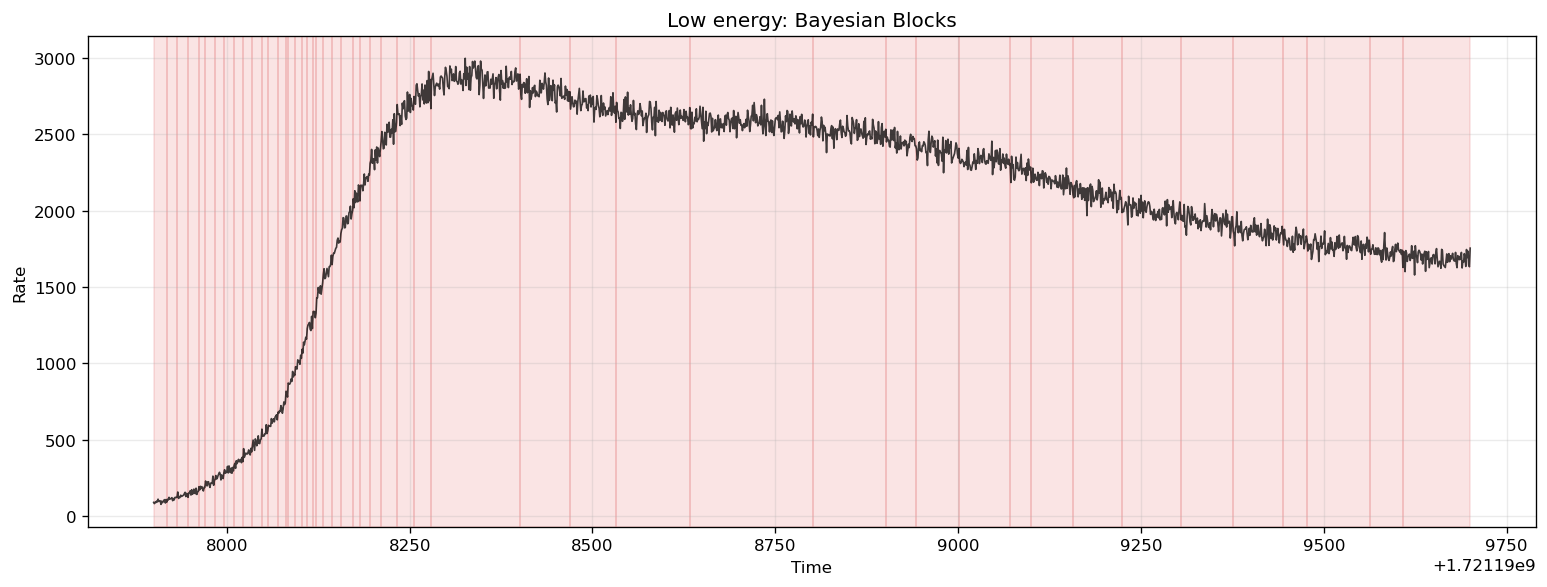

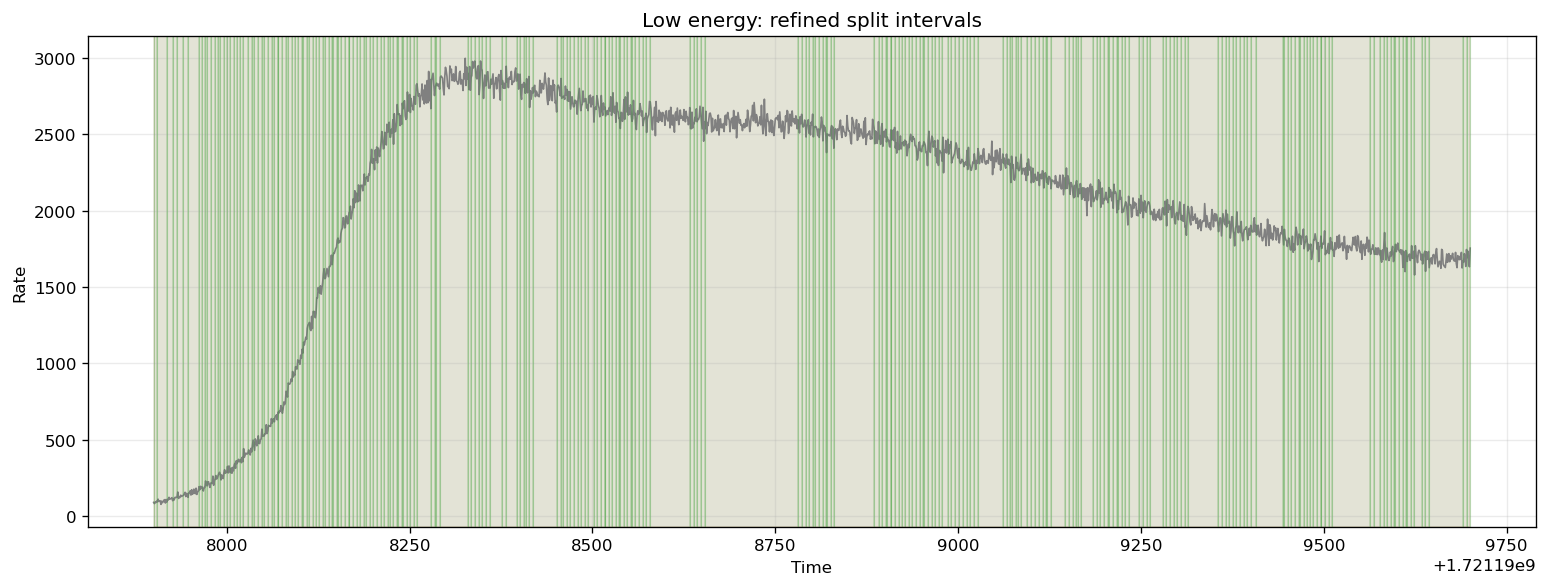

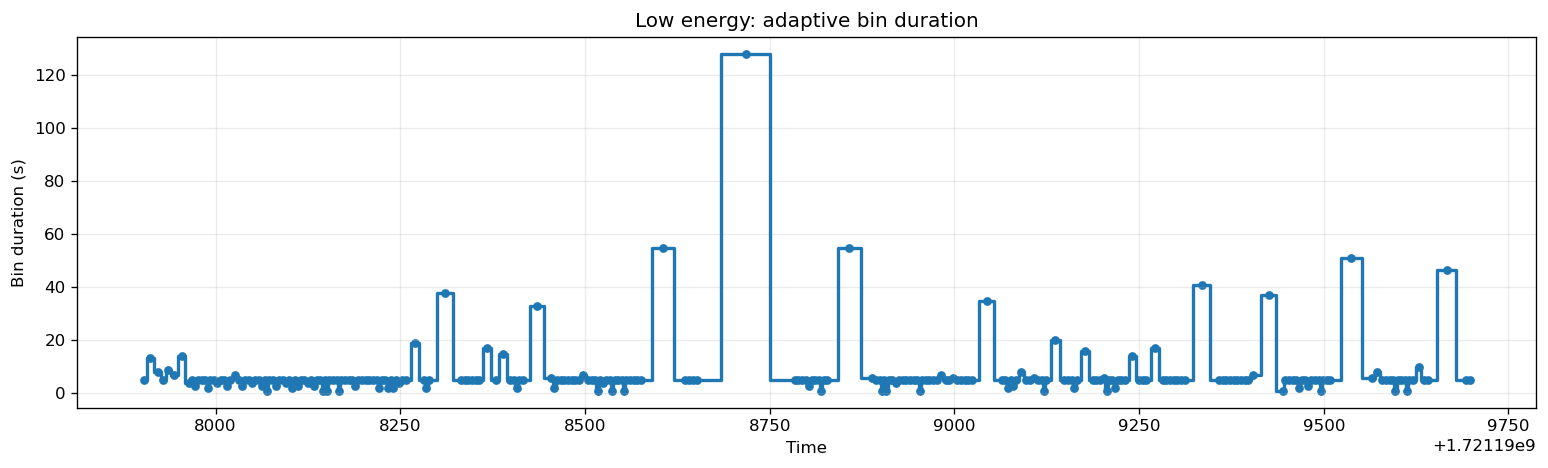

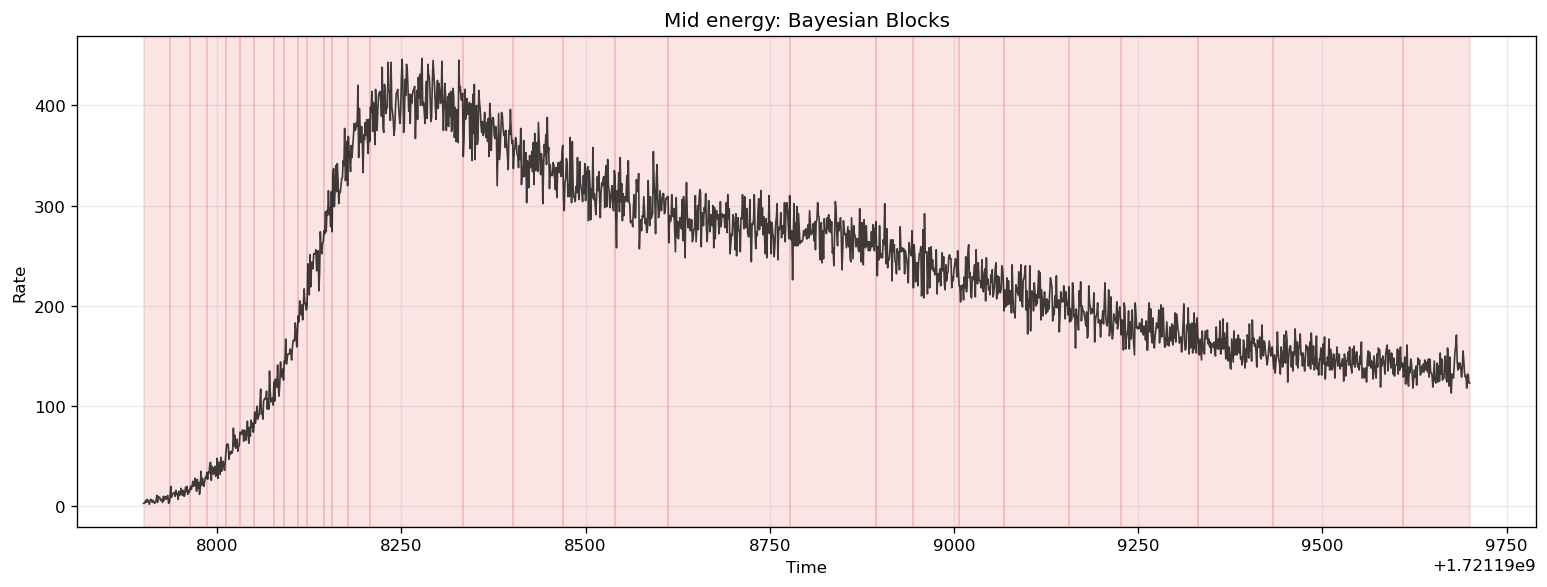

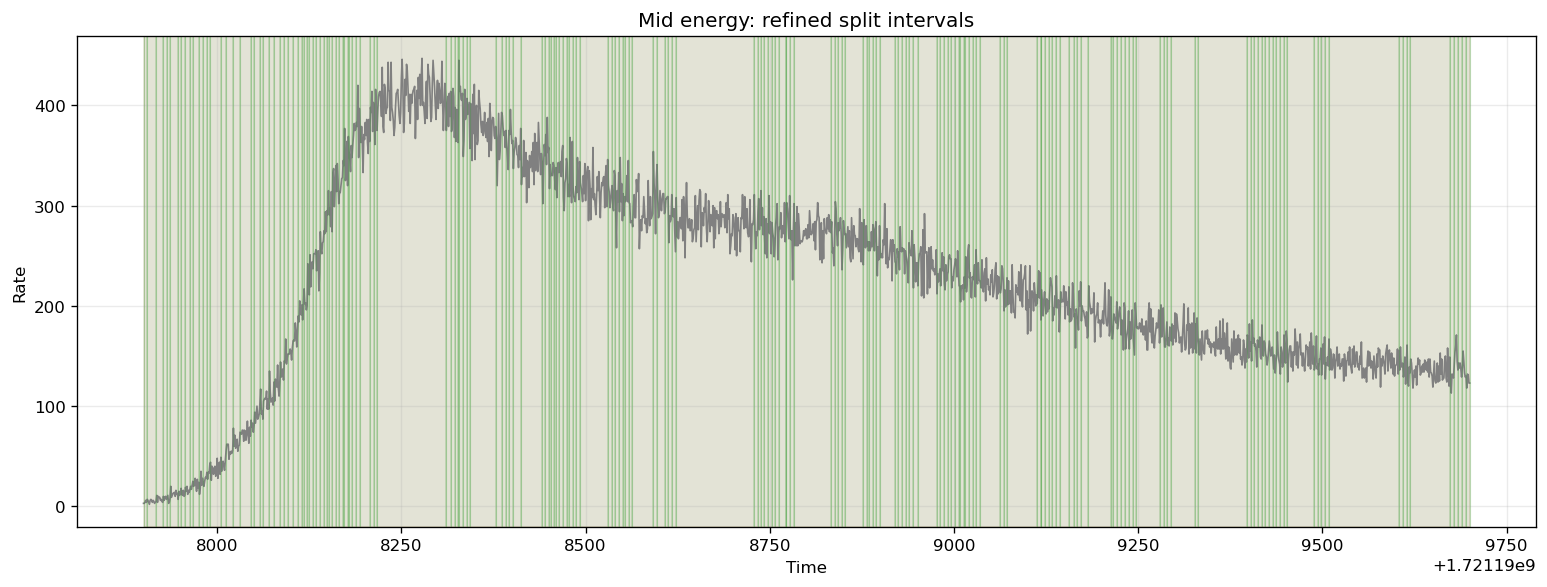

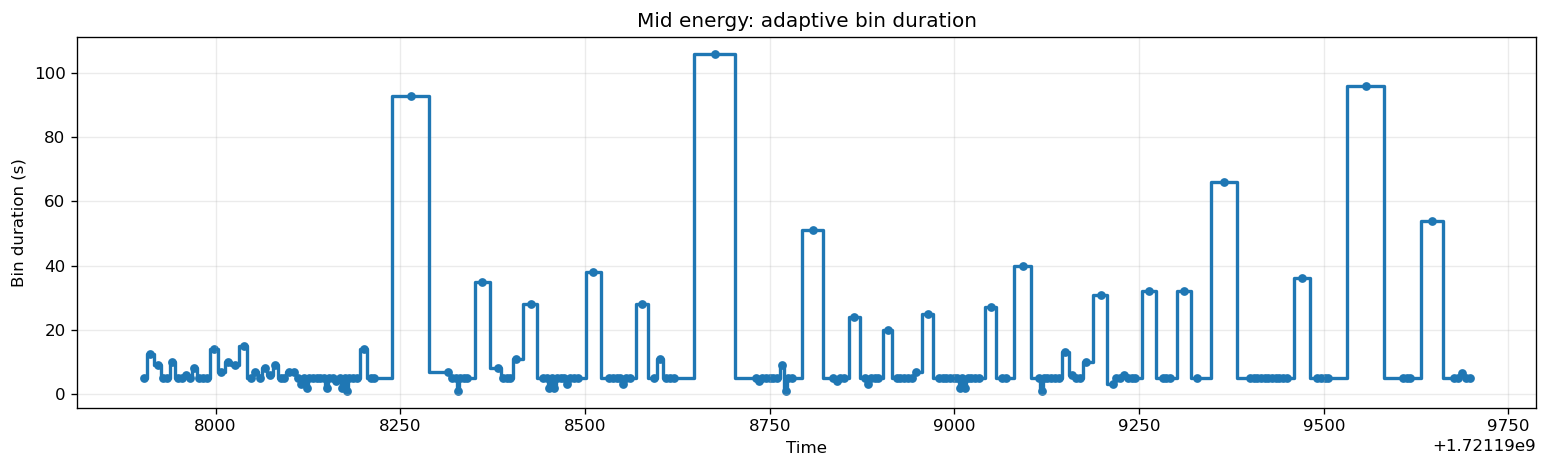

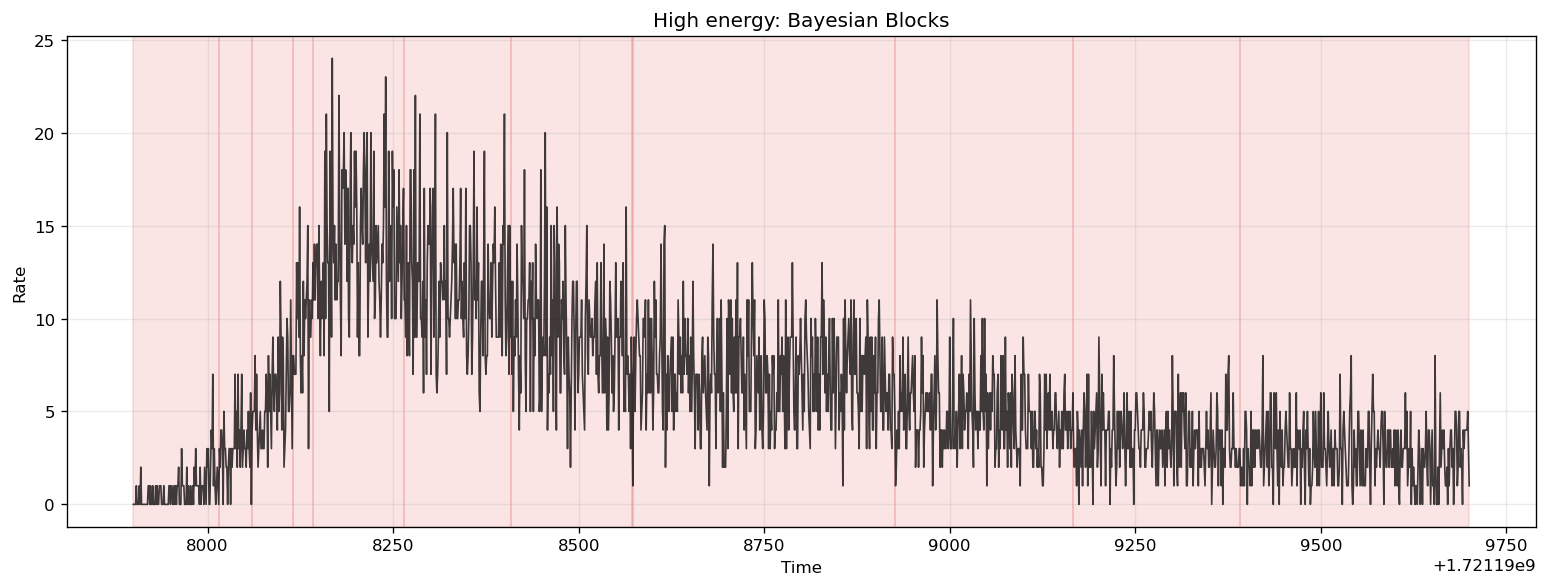

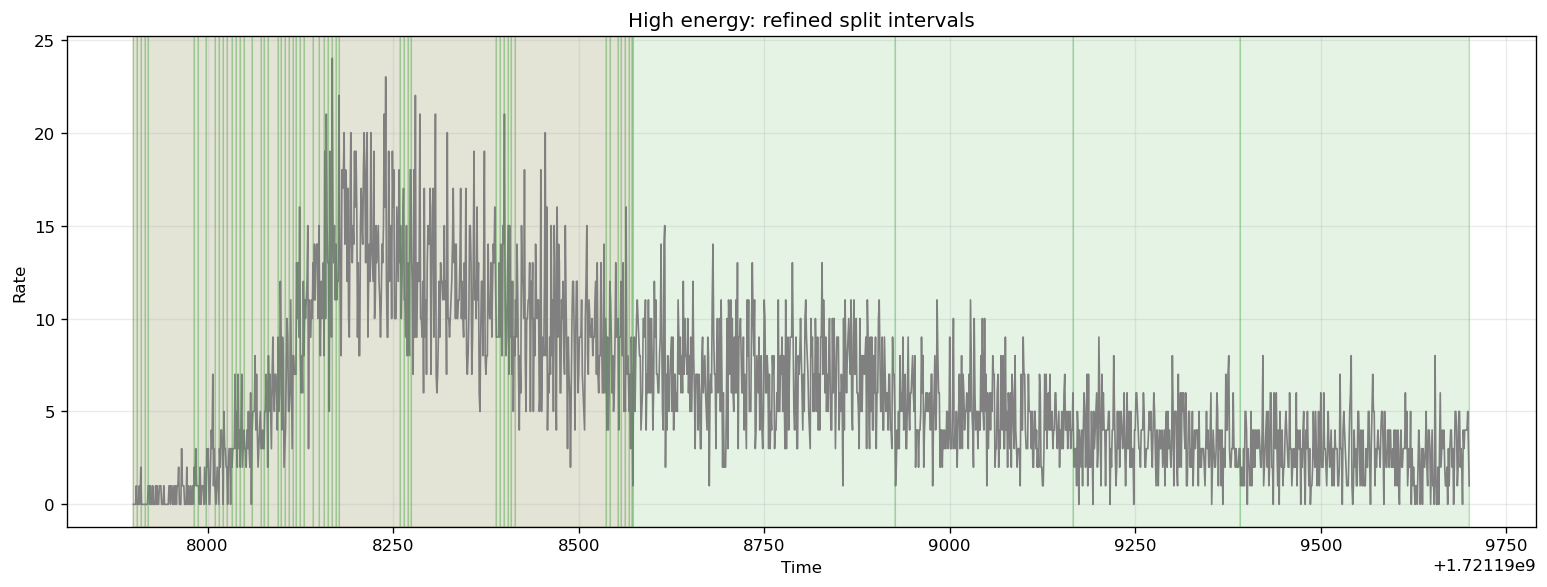

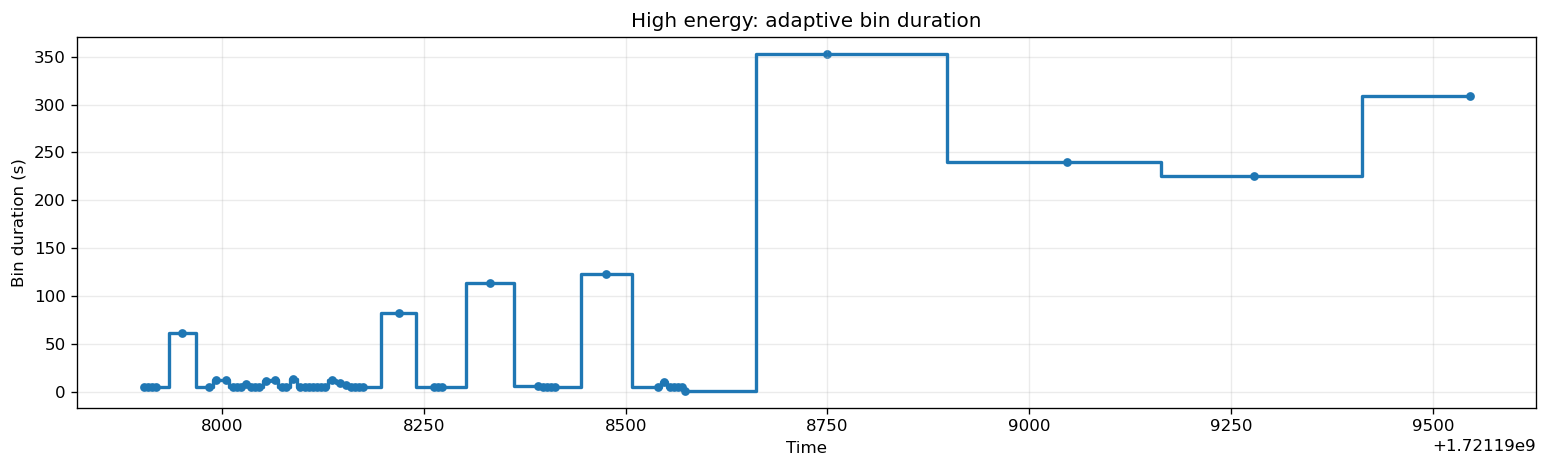

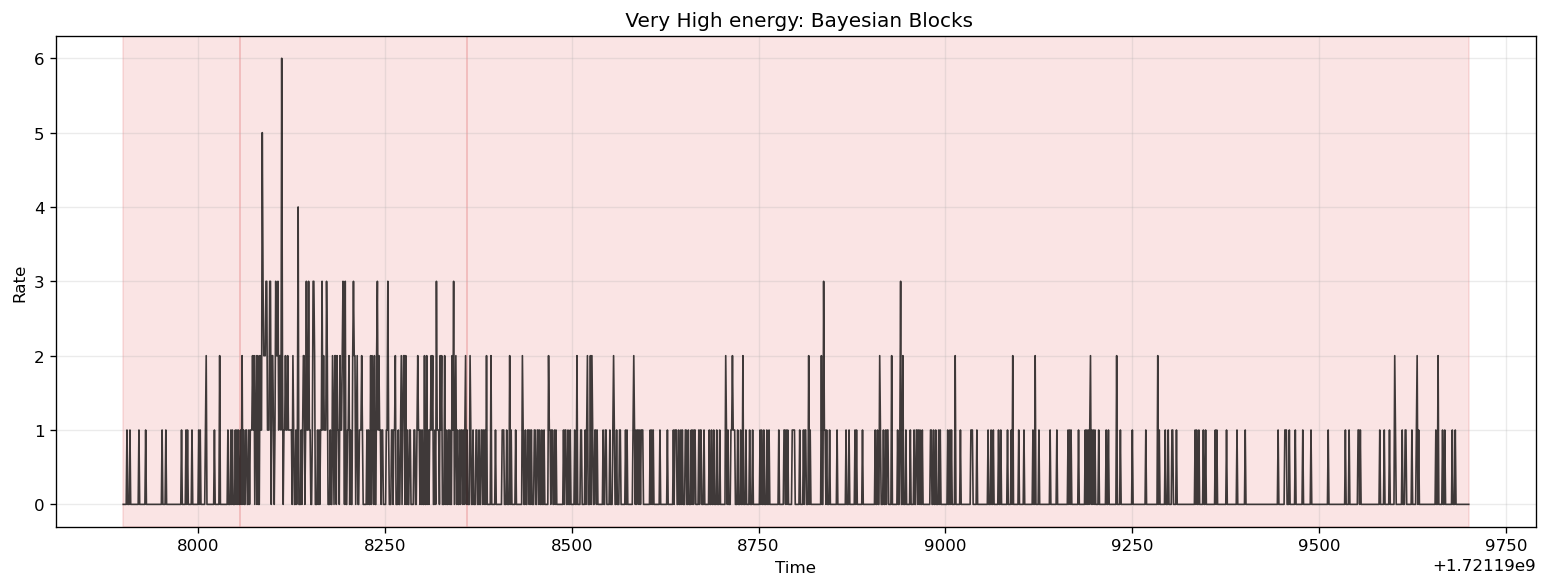

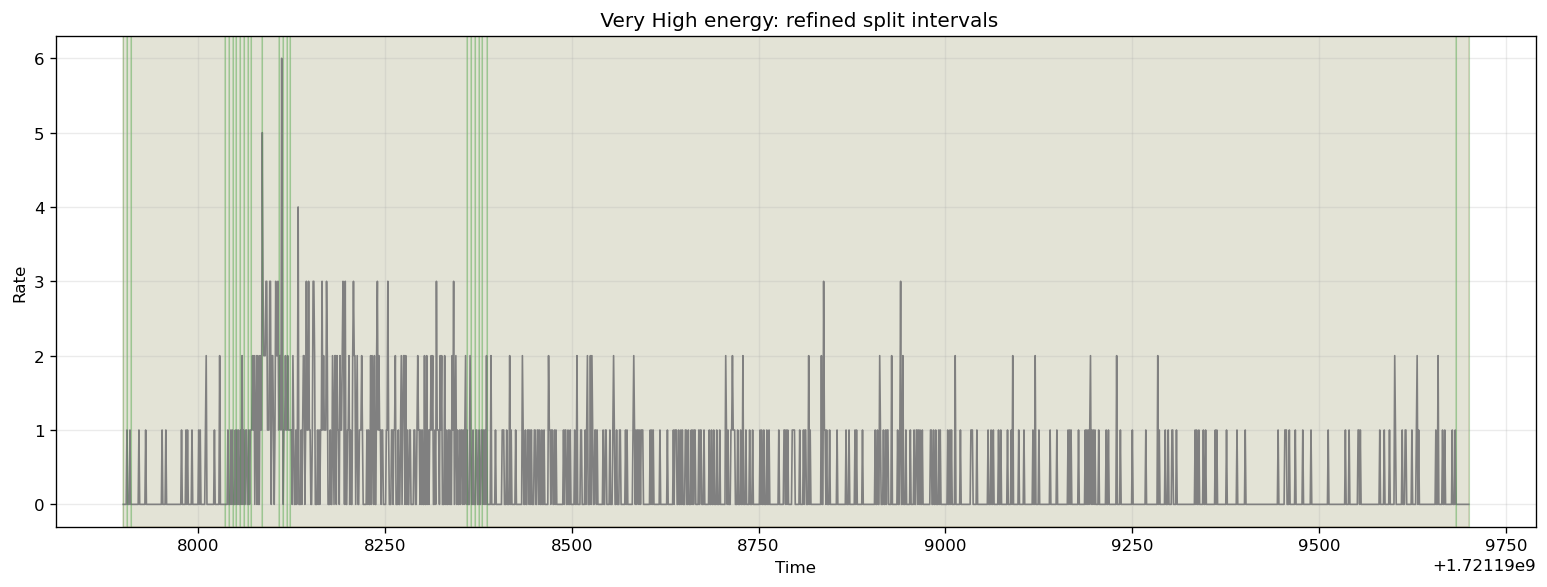

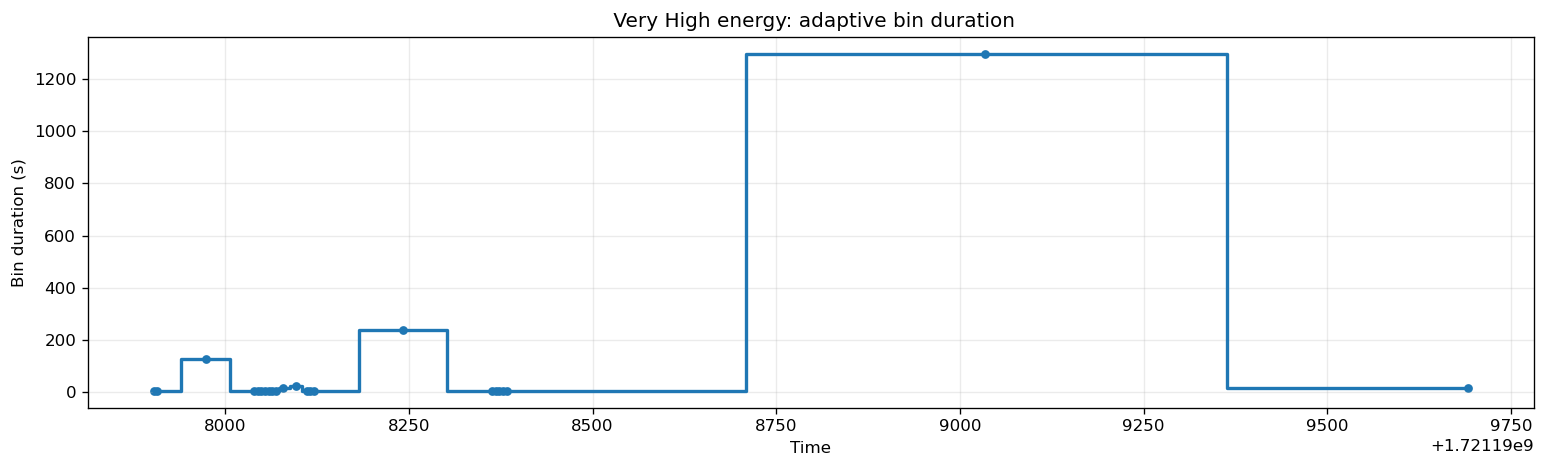

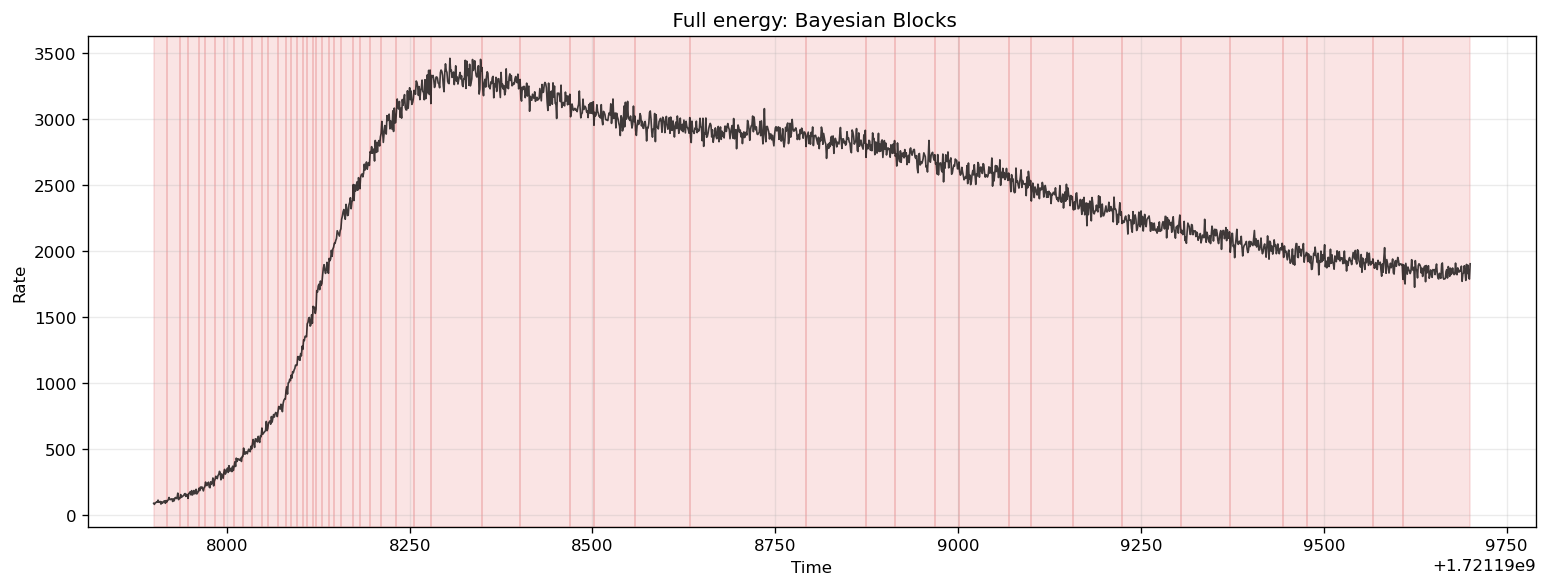

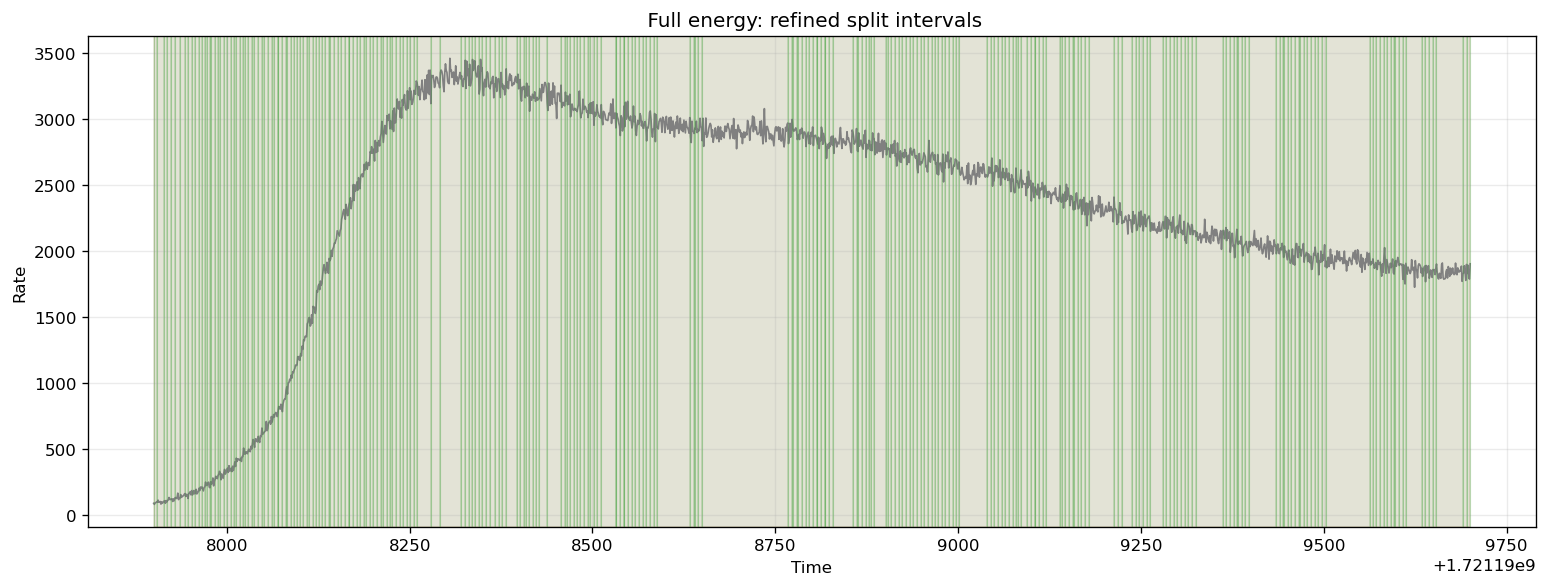

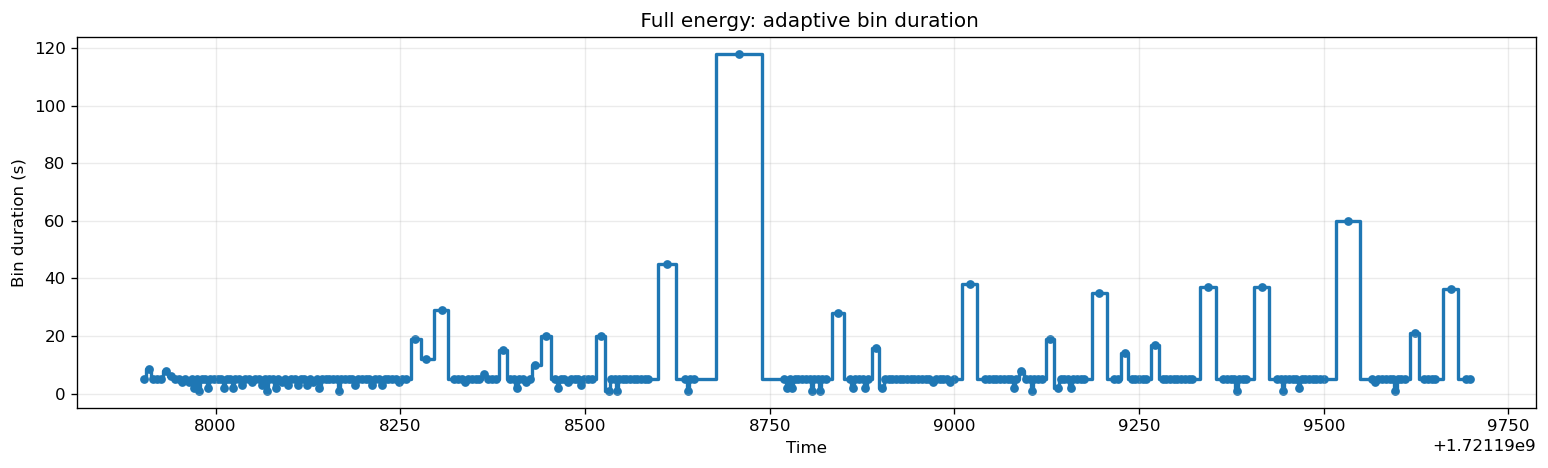

In [8]:
def plot_band_diagnostics(result: Dict[str, Any], outdir: Path) -> None:
    lc: InputLC = result["lc"]
    blocks: pd.DataFrame = result["blocks"]
    refined_df: pd.DataFrame = result["refined_df"]
    label = result["label"]
    name = result["name"]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(lc.time, lc.rate, color="black", lw=1.0, alpha=0.75, label="Light curve")

    for _, row in blocks.iterrows():
        ax.axvspan(row["start"], row["stop"], color="tab:red", alpha=0.12)

    ax.set_title(f"{label}: Bayesian Blocks")
    ax.set_xlabel("Time")
    ax.set_ylabel("Rate")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(outdir / f"{name}_bayesian_blocks.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(lc.time, lc.rate, color="gray", lw=1.0, label="Light curve")

    if len(refined_df):
        for _, row in refined_df.iterrows():
            ax.axvspan(row["start"], row["stop"], color="tab:green", alpha=0.12)
            ax.axvline(row["start"], color="tab:green", alpha=0.25, lw=0.7)
        ax.axvline(refined_df.iloc[-1]["stop"], color="tab:green", alpha=0.25, lw=0.7)

    ax.axvspan(result["meta"]["flare_start"], result["meta"]["flare_stop"], color="tab:red", alpha=0.08, label="Flare region")
    ax.set_title(f"{label}: refined split intervals")
    ax.set_xlabel("Time")
    ax.set_ylabel("Rate")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(outdir / f"{name}_split_intervals.png", dpi=180, bbox_inches="tight")
    plt.show()

    if len(refined_df):
        fig, ax = plt.subplots(figsize=(13, 4))
        ax.step(refined_df["mid_time"], refined_df["duration"], where="mid", color="tab:blue", lw=2)
        ax.scatter(refined_df["mid_time"], refined_df["duration"], color="tab:blue", s=18)
        ax.set_title(f"{label}: adaptive bin duration")
        ax.set_xlabel("Time")
        ax.set_ylabel("Bin duration (s)")
        ax.grid(alpha=0.25)
        fig.tight_layout()
        fig.savefig(outdir / f"{name}_durations.png", dpi=180, bbox_inches="tight")
        plt.show()

for result in band_results.values():
    plot_band_diagnostics(result, OUT_DIR)

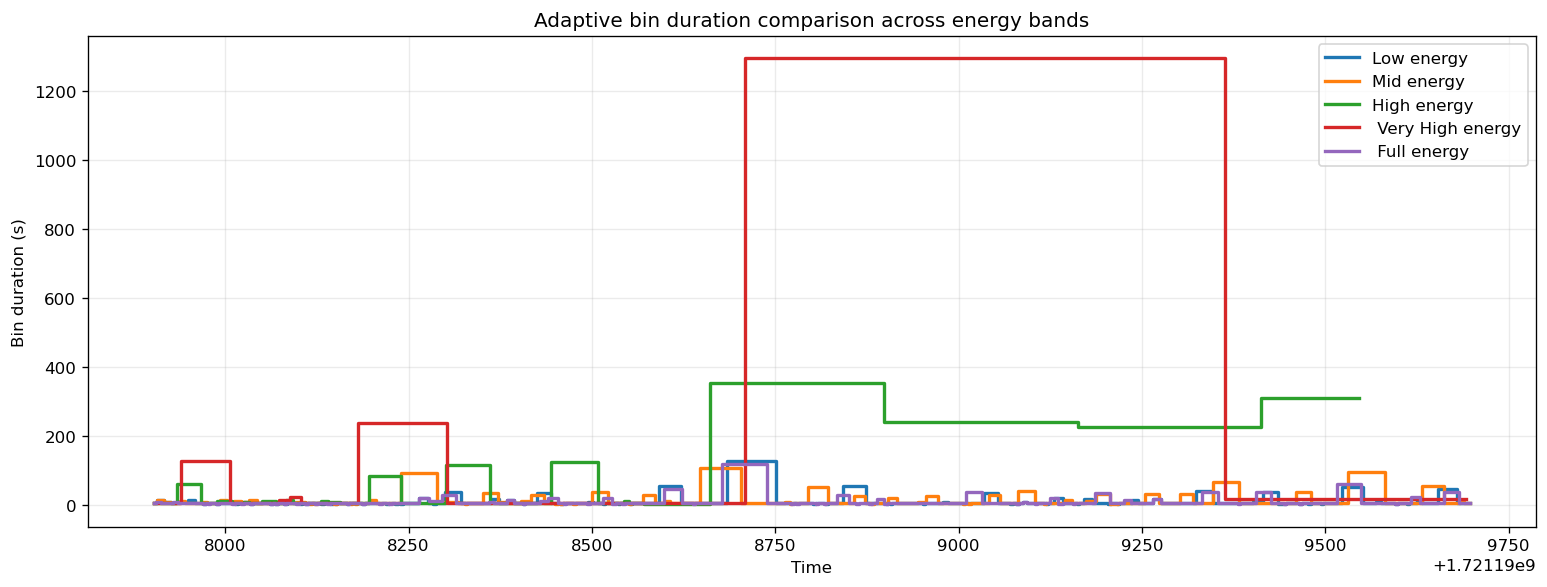

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

for name, result in band_results.items():
    df = result["refined_df"]
    if len(df) == 0:
        continue
    ax.step(df["mid_time"], df["duration"], where="mid", lw=2, label=result["label"])

ax.set_title("Adaptive bin duration comparison across energy bands")
ax.set_xlabel("Time")
ax.set_ylabel("Bin duration (s)")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUT_DIR / "band_duration_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

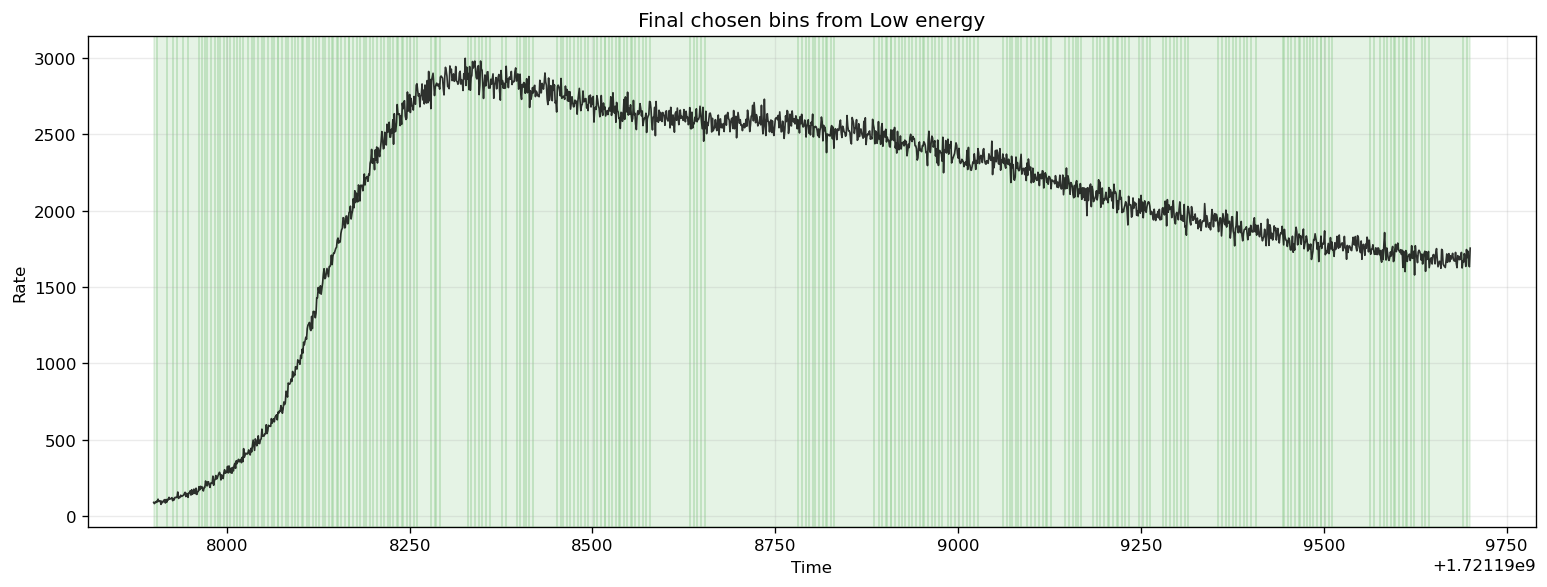

In [10]:
# Show the chosen final bins over the reference band's light curve
ref_lc = reference_band["lc"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ref_lc.time, ref_lc.rate, color="black", lw=1.0, alpha=0.8, label="Reference light curve")

for _, row in final_bins_df.iterrows():
    ax.axvspan(row["start"], row["stop"], color="tab:green", alpha=0.12)

ax.set_title(f"Final chosen bins from {reference_band['label']}")
ax.set_xlabel("Time")
ax.set_ylabel("Rate")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "final_bins_overview.png", dpi=180, bbox_inches="tight")
plt.show()

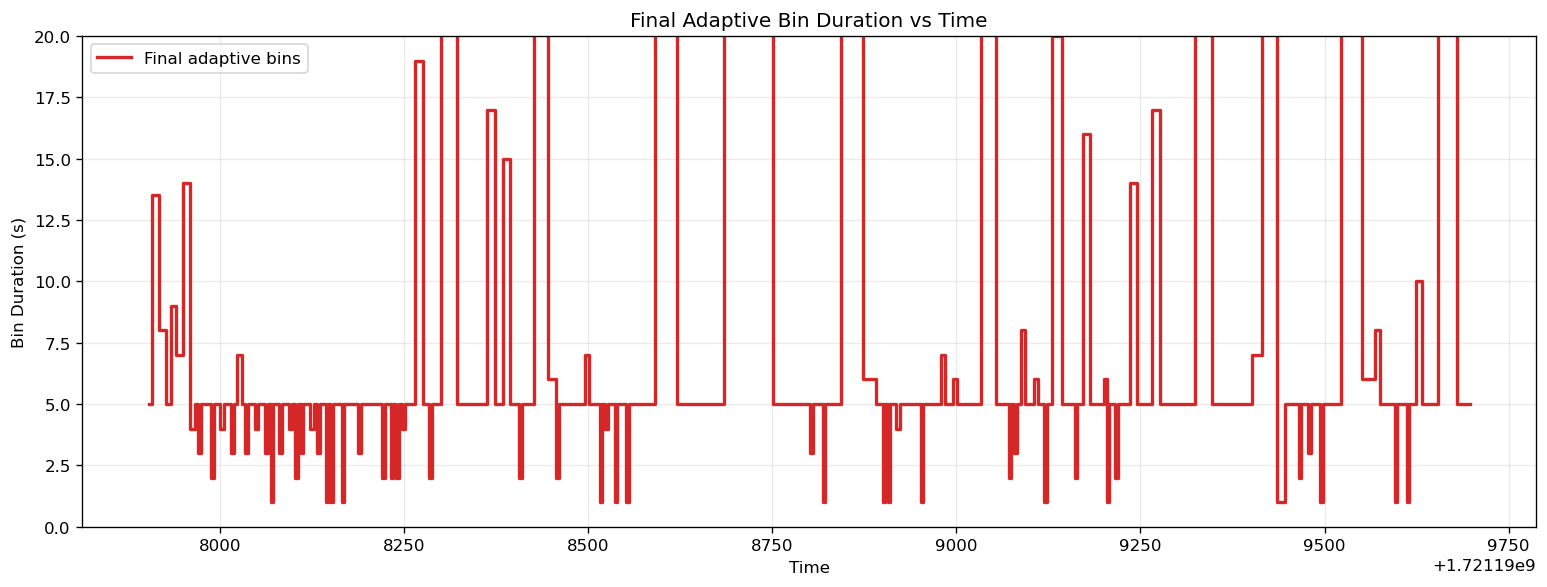

In [17]:
# Compute midpoint of each final adaptive bin
final_bins_df["mid_time"] = (
    final_bins_df["start"] + final_bins_df["stop"]
) / 2

# Plot final bin duration vs time
fig, ax = plt.subplots(figsize=(13, 5))

ax.step(
    final_bins_df["mid_time"],
    final_bins_df["duration"],
    where="mid",
    color="tab:red",
    lw=2,
    label="Final adaptive bins"
)

ax.set_title("Final Adaptive Bin Duration vs Time")
ax.set_xlabel("Time")
ax.set_ylabel("Bin Duration (s)")
ax.set_ylim(0, 20)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(OUT_DIR / "final_bin_duration_vs_time.png",
            dpi=180,
            bbox_inches="tight")

plt.show()

## What to hand over next

At this point the notebook has only the time-segmentation stage.

The next notebook can start from `final_bins_df` and move into:
- spectrum generation,
- response folding,
- thermal fitting,
- uncertainty estimation.

Those pieces are intentionally left out here.